Can we predict which customers are likely to stop purchasing so we can retain them before they leave?

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import joblib

In [2]:
df = pd.read_csv(r"C:\Users\amit6\OneDrive\Desktop\Intelligent-Retail-Customer-Analytics\Data\Processed_data\customer_feature_store.csv")
df.head()

,CustomerID,Frequency,TotalQuantity,Revenue,FirstPurchase,LastPurchase,AverageUnitPrice,UniqueProducts,Country,CustomerTenure,Recency,AverageOrderValue,AverageQuantityPerOrder,WeekendPurchaseRatio,ReturnRate,AverageDaysBetweenOrders
0,12346.0,12,74285,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,6.100000,27,United Kingdom,400,325,6463.038333,6190.416667,0.000000,0.0,35.909091
1,12347.0,8,2967,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00,2.498063,126,Iceland,402,1,615.191250,370.875000,0.180180,0.0,57.000000
2,12348.0,5,2714,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,3.786275,25,Finland,362,74,403.880000,542.800000,0.058824,0.0,90.500000
3,12349.0,4,1624,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,8.459657,138,Italy,570,18,1107.172500,406.000000,0.000000,0.0,189.666667
4,12350.0,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,3.841176,17,Norway,0,309,334.400000,197.000000,0.000000,0.0,0.000000


In [3]:
df["Churn"] = np.where(
    df["Recency"] > 180,
    1,
    0
)

In [4]:
df["Churn"].value_counts()

Churn
0    3480
1    2398
Name: count, dtype: int64

In [6]:
X = df.drop(
    columns=[
        "CustomerID",
        "Churn",
        "Recency",
        "FirstPurchase",
        "LastPurchase"
    ]
)
y =df['Churn']

In [7]:
encoder = LabelEncoder()
X["Country"] = encoder.fit_transform(X["Country"])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [10]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)


In [12]:
print("="*50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*50)

Accuracy : 0.7126
Precision: 0.6310
Recall   : 0.7125
F1 Score : 0.6693


In [13]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.71      0.75       696
           1       0.63      0.71      0.67       480

    accuracy                           0.71      1176
   macro avg       0.71      0.71      0.71      1176
weighted avg       0.72      0.71      0.71      1176



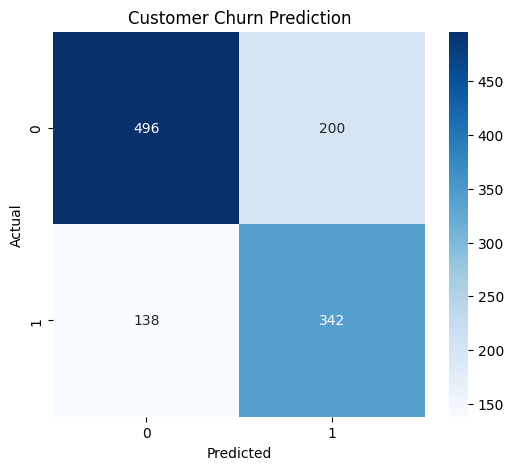

In [14]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Customer Churn Prediction")

plt.show()

In [15]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
6             CustomerTenure    0.244147
1              TotalQuantity    0.128211
2                    Revenue    0.114402
0                  Frequency    0.102128
11  AverageDaysBetweenOrders    0.087922
4             UniqueProducts    0.084647
8    AverageQuantityPerOrder    0.068925
3           AverageUnitPrice    0.068201
7          AverageOrderValue    0.066045
9       WeekendPurchaseRatio    0.022231
5                    Country    0.013140
10                ReturnRate    0.000000


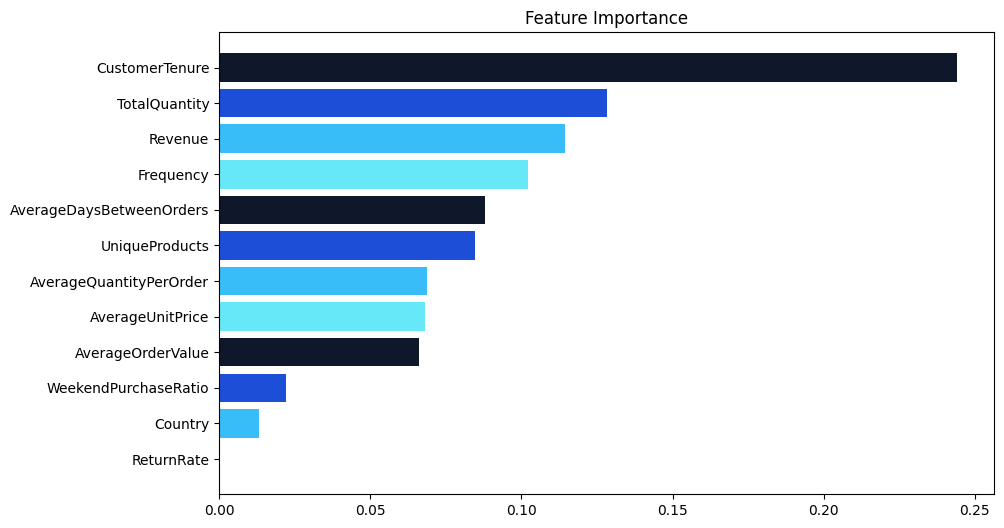

In [19]:
plt.figure(figsize=(10,6))
colors = ['#0F172A', '#1D4ED8', '#38BDF8', '#67E8F9']
plt.barh(
    importance["Feature"],
    importance["Importance"], color = colors
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")

plt.show()

In [20]:
joblib.dump(
    rf,
    "Customer_Churn_RF.pkl"
)

['Customer_Churn_RF.pkl']